In [13]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
path = os.path.join( "..", "data", "processed", "accidents_clean.csv")
df = pd.read_csv(path)

In [14]:
df.drop(columns=['catv_regroup','equipements','age','col','trajet','age', 'atm',
                 'sexe','catu','place','motor','choc','obsm','manv','jour','mois','an','hrmn'], inplace=True)

In [ ]:

#def decimals_for_size(size_m):
#    """Retourne le DEC minimal pour avoir un pas ≤ size_m (latitude)."""
#    return int(np.floor(np.log10(111_320 / size_m)))

#target = 20        # maille voulue en mètres (~10 m)
#DEC = decimals_for_size(target)   # donne 4
#print("DEC à utiliser :", DEC)

DEC à utiliser : 3


In [15]:
# ---------------------------------
# 1. Maillage ~10 m (DEC = 4)
# ---------------------------------
DEC = 4                                 # ≈ 11 m lat × 7 m lon @46 °
df["lat10"] = (df["lat"]  * 10**DEC).round().astype(int)
df["lon10"] = (df["long"] * 10**DEC).round().astype(int)
df["cell_id"] = df["lat10"].astype(str) + "_" + df["lon10"].astype(str)

# ---------------------------------
# 2. Poids de gravité (plus progressifs)
# ---------------------------------
weights = {1: 1, 2: 4, 3: 12, 4: 25}    # à ajuster si besoin
df["score_unit"] = df["grav"].map(weights)   # ← Score pour chaque accident

# ---------------------------------
# 3. Fonction d’encodage de 'lum'
# ---------------------------------
def encode_lum(series):
    """1 si 3 est la plus fréquente (éclairage présent),
       2 si 4 ou 5 le sont (pas d’éclairage),
       0 si aucun 3-4-5 dans la maille."""
    counts = series.value_counts()
    for cat in counts.index:
        if cat == 3:
            return 1
        elif cat in (4, 5):
            return 2
    return 0

# ---------------------------------
# 4. Agrégation
# ---------------------------------
agg_dict = {
    # Variables agrégées comme avant
    "grav":  "median",
    "vma":   lambda s: s.mode().iat[0],
    "obs":   lambda s: s.mode().iat[0],
    "lum":   encode_lum,
    "agg":   lambda s: s.mode().iat[0],
    "int":   lambda s: s.mode().iat[0],
    "catr":  lambda s: s.mode().iat[0],
    "circ":  lambda s: s.mode().iat[0],
    "prof":  lambda s: s.mode().iat[0],
    "plan":  lambda s: s.mode().iat[0],
    "surf":  lambda s: s.mode().iat[0],
    "infra": lambda s: s.mode().iat[0],
    "situ":  lambda s: s.mode().iat[0],
    "dep":   lambda s: s.mode().iat[0],
    "com":   lambda s: s.mode().iat[0],

    # Compteur et score pondéré
    "lat":   "count",                 # nb_accidents (on renommera)
    "score_unit": "sum"               # somme des poids de gravité
}

grid_df = (
    df.groupby("cell_id", as_index=False)
      .agg(agg_dict)
      .rename(columns={
          "lat": "nb_accidents",
          "score_unit": "score"})     # score = Σ poids(grav)
)

# ---------------------------------
# 5. Lissage bayésien + quantiles (facultatif)
# ---------------------------------
mu = grid_df["score"].mean()
alpha = 20
grid_df["score_bayes"] = (grid_df["score"] + alpha * mu) / (1 + alpha)

# Quantiles sur score_bayes (plus discriminant maintenant)
grid_df["risk_class"] = pd.qcut(
    grid_df["score_bayes"].rank(method="first"),  # évite ex-æquo
    5,
    labels=[1, 2, 3, 4, 5]
)

<Axes: title={'center': 'Répartition scores'}, xlabel='Score', ylabel='Nombre de cellules'>

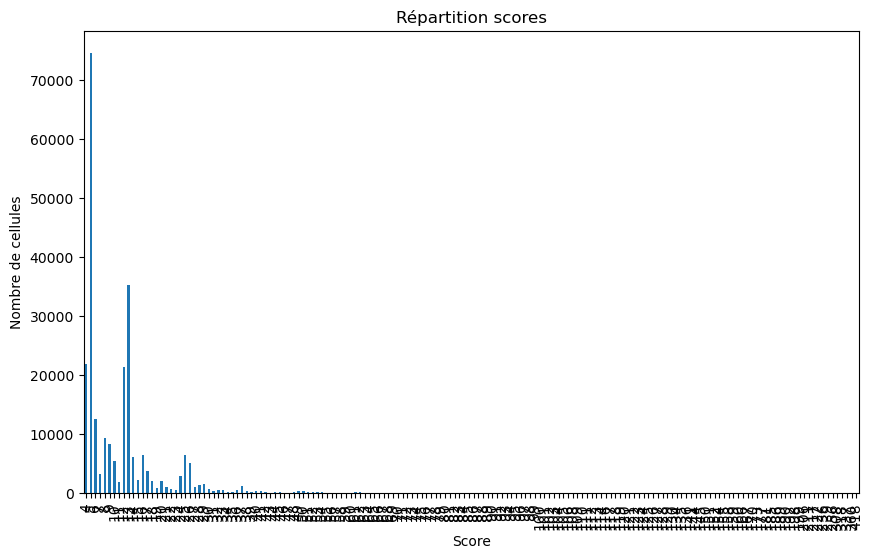

In [24]:
grid_df['score'].value_counts().sort_index().plot(
    kind='bar',
    title='Répartition scores',
    xlabel='Score',
    ylabel='Nombre de cellules',
    figsize=(10, 6)
)

In [64]:
# compte de nombre de zéros dans chaque colonne
zero_counts = grid_df.isin([0]).sum()
zero_counts = zero_counts[zero_counts > 0].sort_values(ascending=False)
print("Nombre de zéros dans chaque colonne :")
print(zero_counts)

Nombre de zéros dans chaque colonne :
infra    224995
obs      214908
lum      194023
dtype: int64


In [10]:
grid_df.isna().sum()/len(grid_df)  # Vérification des NaN

vma           0.0
obs           0.0
lum           0.0
catr          0.0
dep           0.0
risk_class    0.0
dtype: float64

In [16]:
grid_df = grid_df.set_index("cell_id")

In [9]:
grid_df.drop(columns=['grav','nb_accidents','score','score_bayes'], inplace=True)

In [25]:
grid_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246988 entries, -126853_450785 to 635681_8882
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   grav          246988 non-null  float64 
 1   vma           246988 non-null  int64   
 2   obs           246988 non-null  float64 
 3   lum           246988 non-null  int64   
 4   agg           246988 non-null  int64   
 5   int           246988 non-null  float64 
 6   catr          246988 non-null  float64 
 7   circ          246988 non-null  float64 
 8   prof          246988 non-null  float64 
 9   plan          246988 non-null  float64 
 10  surf          246988 non-null  float64 
 11  infra         246988 non-null  float64 
 12  situ          246988 non-null  float64 
 13  dep           246988 non-null  object  
 14  com           246988 non-null  object  
 15  nb_accidents  246988 non-null  int64   
 16  score         246988 non-null  int64   
 17  score_bayes   24

In [17]:
grid_df.head(10)

,grav,vma,obs,lum,agg,int,catr,circ,prof,plan,surf,infra,situ,dep,com,nb_accidents,score,score_bayes,risk_class
cell_id,,,,,,,,,,,,,,,,,,,
-126853_450785,1.0,70,0.0,0,1,1.0,2.0,2.0,2.0,1.0,1.0,0.0,3.0,976,97612,4,15,11.512852,5
-126895_450749,2.0,80,0.0,2,2,1.0,2.0,2.0,1.0,3.0,1.0,0.0,1.0,976,97612,3,9,11.227137,3
-126922_450752,1.0,30,0.0,0,2,1.0,4.0,2.0,2.0,1.0,1.0,0.0,1.0,976,97612,5,16,11.560471,5
-127031_450557,1.0,70,13.0,1,1,1.0,3.0,2.0,2.0,1.0,1.0,0.0,1.0,976,97612,3,27,12.084280,5
-127045_450512,3.0,70,0.0,0,1,1.0,3.0,2.0,1.0,2.0,1.0,0.0,1.0,976,97601,3,25,11.989042,5
-127093_451191,2.0,70,0.0,1,1,1.0,2.0,2.0,2.0,2.0,1.0,0.0,1.0,976,97602,2,13,11.417614,4
-127121_450526,2.0,50,0.0,0,2,1.0,3.0,2.0,1.0,1.0,1.0,0.0,1.0,976,97601,2,13,11.417614,4
-127156_451170,1.5,50,0.0,0,2,1.0,4.0,2.0,1.0,1.0,1.0,0.0,1.0,976,97602,2,5,11.036661,1
-127176_451129,2.5,50,0.0,0,2,1.0,4.0,1.0,1.0,1.0,1.0,0.0,1.0,976,97602,2,26,12.036661,5


In [26]:
grid_df['score'].value_counts()

score
5      74584
13     35311
4      21964
12     21384
6      12580
       ...  
127        1
185        1
192        1
198        1
152        1
Name: count, Length: 164, dtype: int64

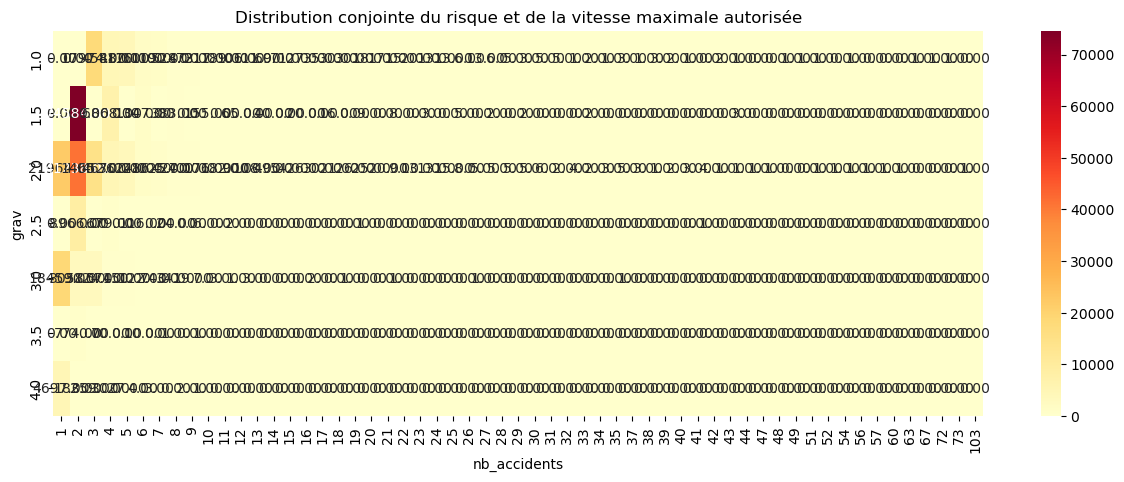

In [135]:
table = pd.crosstab(grid_df["grav"], grid_df["nb_accidents"])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
sns.heatmap(table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title("Distribution conjointe du risque et de la vitesse maximale autorisée")

plt.show()

<Axes: >

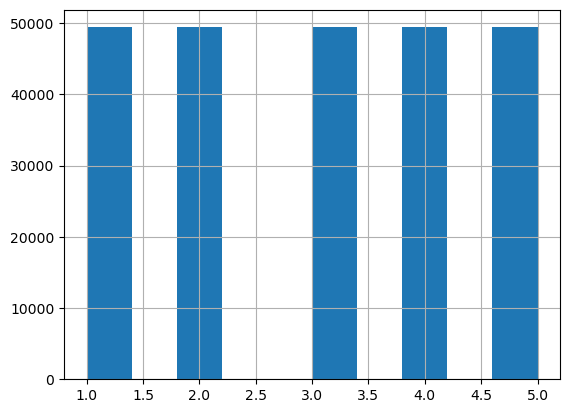

In [138]:
grid_df['risk_class'].hist()

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

def cramers_v_corrected(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan, np.nan  # Trop peu de modalités

    chi2, p, _, _ = chi2_contingency(confusion_matrix, correction=False)
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Correction de biais (Bergsma)
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)

    v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
    return v, p

def analyser_categorielle_v_cramer(df, cat_vars, target, seuil_redondance=0.4):
    print("\n=== 🔍 Association avec la target ===")
    cramer_target = {}
    for var in cat_vars:
        v, p = cramers_v_corrected(df[var], df[target])
        cramer_target[var] = v
        if not np.isnan(v):
            print(f"📌 {var} vs {target} → V de Cramér = {v:.3f}, p = {p:.3g}")

    print("\n=== 🔗 Détection de redondances entre variables catégorielles ===")
    redondantes = []
    for var1, var2 in combinations(cat_vars, 2):
        v, _ = cramers_v_corrected(df[var1], df[var2])
        if not np.isnan(v) and v > seuil_redondance:
            redondantes.append((var1, var2, v))
            print(f"⚠️  {var1} et {var2} sont corrélées (V = {v:.3f})")

    if not redondantes:
        print("✅ Aucune redondance forte détectée.")
    return cramer_target, redondantes

In [19]:
excluded = []
included = [col for col in grid_df.columns if col not in excluded]
target = 'score'
analyser_categorielle_v_cramer(grid_df, included, target)


=== 🔍 Association avec la target ===
📌 grav vs score → V de Cramér = 0.867, p = 0
📌 vma vs score → V de Cramér = 0.161, p = 0
📌 obs vs score → V de Cramér = 0.142, p = 0
📌 lum vs score → V de Cramér = 0.166, p = 0
📌 agg vs score → V de Cramér = 0.336, p = 0
📌 int vs score → V de Cramér = 0.084, p = 0
📌 catr vs score → V de Cramér = 0.114, p = 0
📌 circ vs score → V de Cramér = 0.111, p = 0
📌 prof vs score → V de Cramér = 0.070, p = 0
📌 plan vs score → V de Cramér = 0.129, p = 0
📌 surf vs score → V de Cramér = 0.041, p = 0
📌 infra vs score → V de Cramér = 0.047, p = 0
📌 situ vs score → V de Cramér = 0.174, p = 0
📌 dep vs score → V de Cramér = 0.045, p = 0
📌 com vs score → V de Cramér = 0.091, p = 0
📌 nb_accidents vs score → V de Cramér = 0.595, p = 0
📌 score vs score → V de Cramér = 1.000, p = 0
📌 score_bayes vs score → V de Cramér = 1.000, p = 0
📌 risk_class vs score → V de Cramér = 0.858, p = 0

=== 🔗 Détection de redondances entre variables catégorielles ===
⚠️  grav et score sont co

({'grav': 0.8673450231305627,
  'vma': 0.1607539434419767,
  'obs': 0.14203803589663908,
  'lum': 0.16590847386734894,
  'agg': 0.33606067775126086,
  'int': 0.08399724675903016,
  'catr': 0.11376530708490669,
  'circ': 0.11060637441845869,
  'prof': 0.06970888744305258,
  'plan': 0.12892298125081947,
  'surf': 0.04092717300800722,
  'infra': 0.046510654662988024,
  'situ': 0.17417440570740497,
  'dep': 0.04452174234039629,
  'com': 0.09055619067728264,
  'nb_accidents': 0.5948611222850763,
  'score': 1.0,
  'score_bayes': 1.0,
  'risk_class': 0.8582888571380454},
 [('grav', 'score', 0.8673450231305627),
  ('grav', 'score_bayes', 0.8673450231305627),
  ('grav', 'risk_class', 0.4999829543301292),
  ('vma', 'agg', 0.8485330146281936),
  ('vma', 'com', 0.4818091455471281),
  ('agg', 'catr', 0.6020769657136629),
  ('agg', 'com', 0.6326840684405651),
  ('catr', 'com', 0.4194140068890309),
  ('dep', 'com', 0.952546074499272),
  ('nb_accidents', 'score', 0.5948611222850763),
  ('nb_accidents'

In [ ]:
# Suppression des colonnes inutiles V Cramer < 0.1
grid_df = grid_df.drop(columns=['int','circ','prof','plan','surf','infra','situ'])

# Suppression des varaibles redondantes
grid_df = grid_df.drop(columns=['agg','com'])

In [32]:
grid_df_2 = grid_df.drop(columns=['grav','nb_accidents','risk_class','score_bayes'])

In [33]:
grid_df_2 = grid_df_2.drop(columns=['int','prof','surf','infra','situ','dep','com','agg'])

In [37]:
grid_df_3 = grid_df.drop(columns=['grav','nb_accidents','risk_class','score'])
grid_df_3 = grid_df_3.drop(columns=['int','prof','surf','infra','situ','dep','com','agg'])

In [38]:
grid_df_3.head(10)

,vma,obs,lum,catr,circ,plan,score_bayes
cell_id,,,,,,,
-126853_450785,70,0.0,0,2.0,2.0,1.0,11.512852
-126895_450749,80,0.0,2,2.0,2.0,3.0,11.227137
-126922_450752,30,0.0,0,4.0,2.0,1.0,11.560471
-127031_450557,70,13.0,1,3.0,2.0,1.0,12.084280
-127045_450512,70,0.0,0,3.0,2.0,2.0,11.989042
-127093_451191,70,0.0,1,2.0,2.0,2.0,11.417614
-127121_450526,50,0.0,0,3.0,2.0,1.0,11.417614
-127156_451170,50,0.0,0,4.0,2.0,1.0,11.036661
-127176_451129,50,0.0,0,4.0,1.0,1.0,12.036661


In [40]:
grid_df_4 = grid_df.drop(columns=['grav','score_bayes','risk_class','score'])
grid_df_4 = grid_df_4.drop(columns=['int','prof','surf','infra','situ','dep','com','agg'])

In [41]:
grid_df_4.head(10)

,vma,obs,lum,catr,circ,plan,nb_accidents
cell_id,,,,,,,
-126853_450785,70,0.0,0,2.0,2.0,1.0,4
-126895_450749,80,0.0,2,2.0,2.0,3.0,3
-126922_450752,30,0.0,0,4.0,2.0,1.0,5
-127031_450557,70,13.0,1,3.0,2.0,1.0,3
-127045_450512,70,0.0,0,3.0,2.0,2.0,3
-127093_451191,70,0.0,1,2.0,2.0,2.0,2
-127121_450526,50,0.0,0,3.0,2.0,1.0,2
-127156_451170,50,0.0,0,4.0,2.0,1.0,2
-127176_451129,50,0.0,0,4.0,1.0,1.0,2


<Axes: >

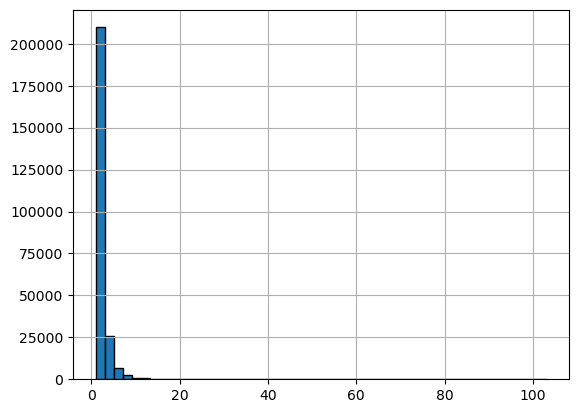

In [42]:
grid_df_4['nb_accidents'].hist(bins=50, edgecolor='black')

In [34]:
grid_df_2.head(10)

,vma,obs,lum,catr,circ,plan,score
cell_id,,,,,,,
-126853_450785,70,0.0,0,2.0,2.0,1.0,15
-126895_450749,80,0.0,2,2.0,2.0,3.0,9
-126922_450752,30,0.0,0,4.0,2.0,1.0,16
-127031_450557,70,13.0,1,3.0,2.0,1.0,27
-127045_450512,70,0.0,0,3.0,2.0,2.0,25
-127093_451191,70,0.0,1,2.0,2.0,2.0,13
-127121_450526,50,0.0,0,3.0,2.0,1.0,13
-127156_451170,50,0.0,0,4.0,2.0,1.0,5
-127176_451129,50,0.0,0,4.0,1.0,1.0,26


In [11]:
grid_df.to_csv("../data/processed/risk_preprocessed.csv", index=False)

In [36]:
grid_df_2.to_csv("../data/processed/score_preprocessed.csv", index=False)

In [39]:
grid_df_3.to_csv("../data/processed/score_bayes_preprocessed.csv", index=False)